# Relative abundance of  pEMT, Mesenchymal and Classical states in RMC

This analysis looks at the relative abundance of pEMT, Mesenchymal and Classical states within the tumor, comparing the treated samples against control samples at 7D and Endpoint

In [1]:
"""Load the Adata file """

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os
import pandas as pd
import seaborn as sns
import scanpy as sc
from pylab import *
import numpy as np


writeDir='/...'
OutDir = '/...'
cellType = 'Epithelial'
case_name='Relapsed_Tumors'



expression_df = pd.read_csv('')
metadata = pd.read_csv('')

adata = sc.AnnData(X=expression_df)
adata.obs = metadata
adata.obsm['X_umap'] = metadata_df[['UMAP_1', 'UMAP_2']].to_numpy()


In [2]:
""" Append Dilly sig info """

nmf = pd.read_excel('.../KPC17_vs_Veh/code/cd-24-0177_supplemental_table_8_suppst8.xlsx', 
                    skiprows=2)

nmf = nmf[['Cell cycle', 'Classical', 'Hypoxia', 'Mesenchymal','Neural-like progenitor', 'pEMT']]
nmf_dict = nmf.to_dict('list')

for i in nmf_dict:
    genes = nmf_dict[i]
    genes_cleaned = [x for x in genes if x in adata.var_names]
    adata.obs[i] = adata[:,genes_cleaned].X.mean(1)


In [3]:
"""select the top 25% of cells with the highest scores"""

focus_group = ['Classical','pEMT','Mesenchymal']

dfb = pd.DataFrame(adata.obs.groupby("batch").size(), columns=["Total"])
master = pd.DataFrame()
master = pd.concat([master, dfb], axis=1)


for i in focus_group:
    threshold = np.percentile(adata.obs[i], 75)
    adata.obs[i + "_Filtered"] = np.where(adata.obs[i] >= threshold, "Top 25%", "Rest")
    adata.obs[i + "_Filtered"] = adata.obs[i + "_Filtered"].astype("category")
    adata.obs[i + "_Filtered"] = adata.obs[i + "_Filtered"].cat.reorder_categories(["Rest", "Top 25%"])
    
    df = pd.DataFrame(adata.obs[i + "_Filtered"])
    df1 = pd.DataFrame(adata.obs['batch'])
    df2 = pd.DataFrame(adata.obs['cohort'])
    df = pd.concat([df, df1, df2],axis=1)
    pivot_prep = pd.crosstab(df["cohort"], df["batch"])
    df = df[~df[i + "_Filtered"].str.contains("Rest", case=False, na=False)]
    dfb = pd.DataFrame(adata.obs.groupby('batch').size(), columns=["Total"])
    
    df = df[~df[i + "_Filtered"].str.contains("Rest", case=False, na=False)]
    pivot = pd.crosstab(df["cohort"], df["batch"])
    
    #add to master
    result_df = df.groupby("batch").size().reset_index(name=i)
    result_df = result_df.set_index("batch")
    result_df.index.name = None
    
    master = pd.concat([master, result_df], axis=1)


pEMT (Endpoint) -> Veh: 0.3771 | RM-042: 0.3232 | Log2FC: -0.22


/tmp/ipykernel_1669248/3504001758.py:71: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels, rotation=45, ha="right")


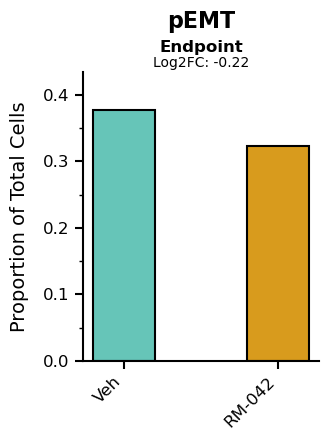

pEMT (7D) -> Veh: 0.2861 | RM-042: 0.0694 | Log2FC: -2.04


/tmp/ipykernel_1669248/3504001758.py:71: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels, rotation=45, ha="right")


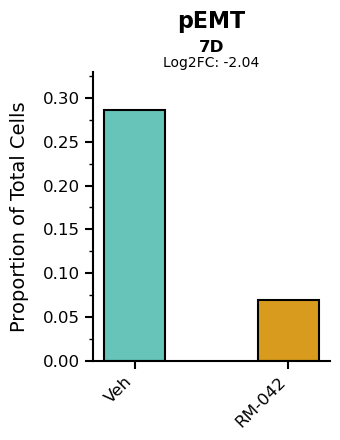

Mesenchymal (Endpoint) -> Veh: 0.2720 | RM-042: 0.0294 | Log2FC: -3.21


/tmp/ipykernel_1669248/3504001758.py:71: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels, rotation=45, ha="right")


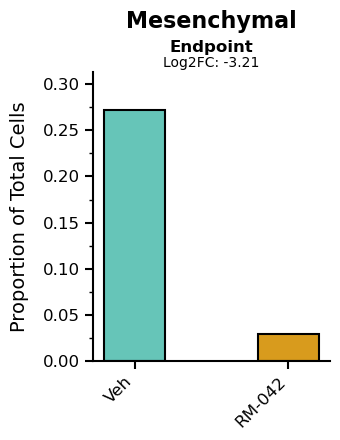

Mesenchymal (7D) -> Veh: 0.4072 | RM-042: 0.1139 | Log2FC: -1.84


/tmp/ipykernel_1669248/3504001758.py:71: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels, rotation=45, ha="right")


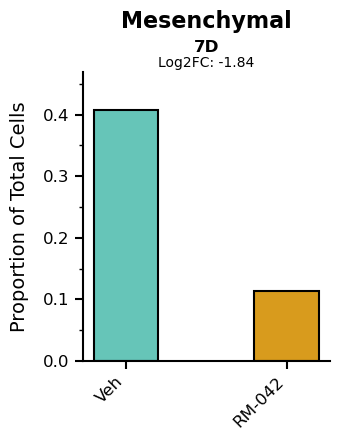

Classical (Endpoint) -> Veh: 0.2102 | RM-042: 0.4235 | Log2FC: 1.01


/tmp/ipykernel_1669248/3504001758.py:71: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels, rotation=45, ha="right")


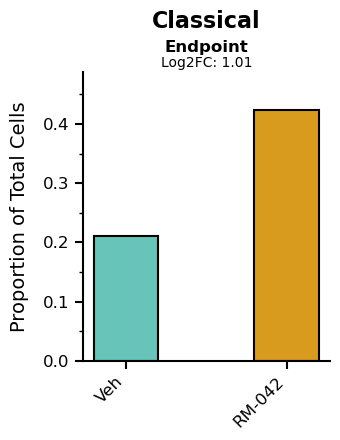

Classical (7D) -> Veh: 0.0851 | RM-042: 0.4417 | Log2FC: 2.38


/tmp/ipykernel_1669248/3504001758.py:71: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels, rotation=45, ha="right")


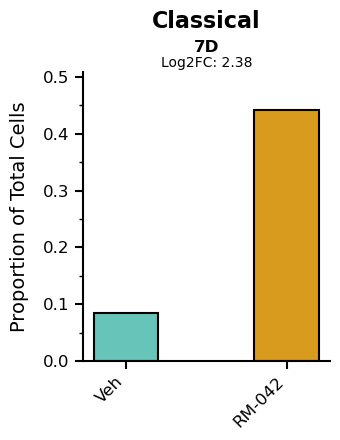

In [4]:
"""generate plots """

# plotting Variables
timepoints = {"Endpoint": {"Veh_samples": ["Vehicle_1", "Vehicle_2"],
                           "Treat_samples": ["RM-042_1", "RM-042_2"]},
              "7D": {"Veh_samples": ["Vehicle_7D_1", "Vehicle_7D_2"],
                     "Treat_samples": ["RM-042_7D_1", "RM-042_7D_2"]}
             }

populations = ["pEMT", "Mesenchymal", "Classical"]
colors = ["#66C5B8", "#D89B1D"]  # Teal for Veh, Gold for RM-042
labels = ["Veh", "RM-042"]

# barplots
for pop in populations:
    for tp_name, samples in timepoints.items():
        veh_pop_sum =  master.loc[samples["Veh_samples"], pop].sum()
        veh_total_sum =  master.loc[samples["Veh_samples"], "Total"].sum()
        treat_pop_sum =  master.loc[samples["Treat_samples"], pop].sum()
        treat_total_sum =  master.loc[samples["Treat_samples"], "Total"].sum()

        # Normalization
        prop_veh = veh_pop_sum / veh_total_sum if veh_total_sum > 0 else 0
        prop_treat = (
            treat_pop_sum / treat_total_sum if treat_total_sum > 0 else 0
        )
        proportions = [prop_veh, prop_treat]

        # Calculate descriptive stats for tracking
        fc = prop_treat / prop_veh if prop_veh > 0 else 0
        log2fc = np.log2(fc) if fc > 0 else 0
        print(f"{pop} ({tp_name}) -> Veh: {prop_veh:.4f} | RM-042: {prop_treat:.4f} | Log2FC: {log2fc:.2f}")

        fig, ax = plt.subplots(figsize=(3.5, 4.5))
        ax.bar(
            labels,
            proportions,
            color=colors,
            edgecolor="black",
            linewidth=1.5,
            width=0.4,
        )

        #title
        ax.set_title(pop, fontsize=16, fontweight="bold", pad=32)
        #subtitle
        ax.text(
            0.5,
            1.06,
            tp_name,
            fontsize=12,
            fontweight="bold",
            ha="center",
            va="bottom",
            transform=ax.transAxes,
        )

        ax.text(
            0.5,
            1.01,
            f"Log2FC: {log2fc:.2f}",
            fontsize=10,
            fontweight="normal",
            ha="center",
            va="bottom",
            transform=ax.transAxes,
        )
        
        
        ax.set_ylabel("Proportion of Total Cells", fontsize=14, labelpad=10)
        ax.set_xticklabels(labels, rotation=45, ha="right")

        # Clean borders
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(1.5)
        ax.spines["bottom"].set_linewidth(1.5)
        ax.grid(False)

        # Tick adjustments
        ax.tick_params(
            axis="both",
            which="major",
            direction="out",
            labelsize=12,
            width=1.5,
            size=6,
        )
        ax.tick_params(axis="y", which="minor", direction="out", width=1, size=3)
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

        # Iincrease vertical limit
        max_val = max(proportions) if max(proportions) > 0 else 0.1
        ax.set_ylim(0, max_val * 1.15)

        plt.tight_layout()
        filename = f"{pop}_{tp_name}_barplot_0823.png".lower()
        #plt.savefig(OutDir + filename, transparent=True, dpi=300)
        plt.show()
        plt.close()

# RAS gene expressio in 5-Ph-IAA (Auxin model)

In [5]:
""" Load the data """

case_name ='Auxin'
cellType = 'Epithelial'

writeDir='/...'
OutDir = '/...'
cellType = 'Epithelial'
case_name='Auxin'



expression_df = pd.read_csv('')
metadata = pd.read_csv('')

adata = sc.AnnData(X=expression_df)
adata.obs = metadata
adata.obsm['X_umap'] = metadata_df[['UMAP_1', 'UMAP_2']].to_numpy()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

VEH_2_5-Ph-IAA vs. 5-Ph-IAA_1: Mann-Whitney-Wilcoxon test two-sided, P_val:9.510e-106 U_stat=1.194e+06
VEH_1_5-Ph-IAA vs. 5-Ph-IAA_1: Mann-Whitney-Wilcoxon test two-sided, P_val:1.043e-122 U_stat=1.277e+06


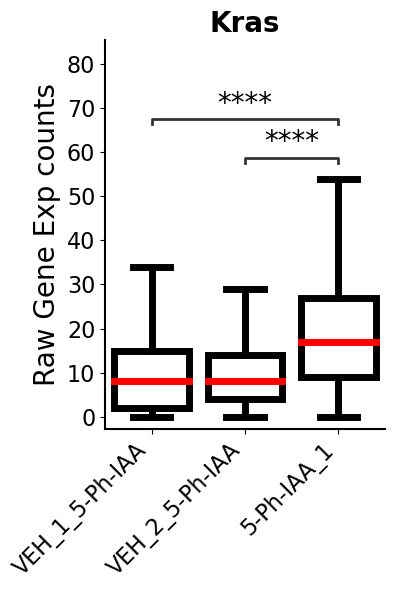

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

VEH_2_5-Ph-IAA vs. 5-Ph-IAA_1: Mann-Whitney-Wilcoxon test two-sided, P_val:5.601e-116 U_stat=1.162e+06
VEH_1_5-Ph-IAA vs. 5-Ph-IAA_1: Mann-Whitney-Wilcoxon test two-sided, P_val:6.062e-101 U_stat=1.371e+06


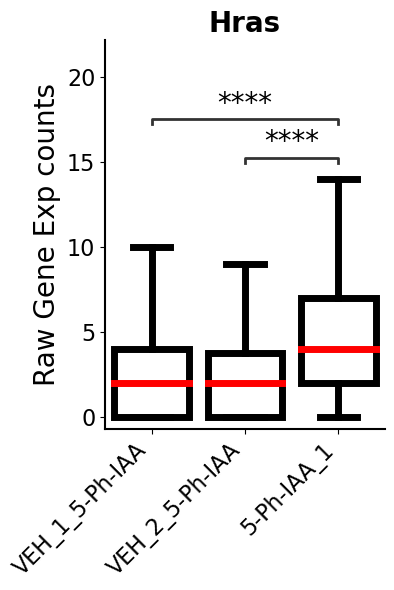

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

VEH_2_5-Ph-IAA vs. 5-Ph-IAA_1: Mann-Whitney-Wilcoxon test two-sided, P_val:3.063e-122 U_stat=1.140e+06
VEH_1_5-Ph-IAA vs. 5-Ph-IAA_1: Mann-Whitney-Wilcoxon test two-sided, P_val:1.999e-99 U_stat=1.378e+06


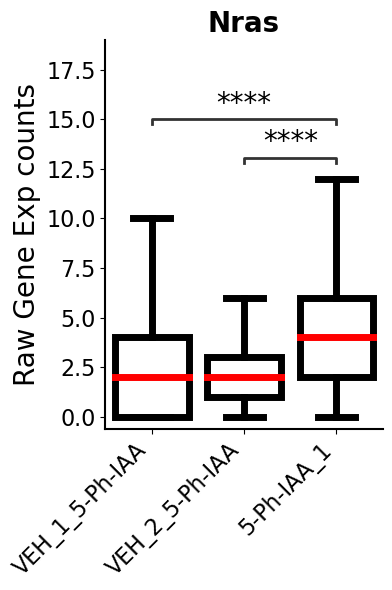

In [6]:
""" Ras expression plots with statistics """

from statannotations.Annotator import Annotator

ras_genes = ['Kras', 'Hras', 'Nras']
plot_samples = ['VEH_1_5-Ph-IAA', 'VEH_2_5-Ph-IAA', '5-Ph-IAA_1']

for j in ras_genes:
    gene_data = {}
    
    for i in samples:
        adata = adata
        cells_keep = adata.obs_names[(adata.obs['batch'].isin([i]))]
        adata = adata[cells_keep, :]
    
        expr_vals = adata[:, j].X.mean(axis=1)
        if hasattr(expr_vals, "toarray"):
            expr_vals = expr_vals.toarray().flatten()
        else:
            expr_vals = np.asarray(expr_vals).flatten()
            
        gene_data[i] = pd.Series(expr_vals)
        
    
    combined_data = pd.DataFrame(gene_data)
    available_samples = [s for s in plot_samples if s in combined_data.columns]
    combined_data = combined_data[available_samples]

    
    melted = combined_data.melt(var_name='Group', value_name='Expression')

    
    boxprops = dict(facecolor='white', edgecolor='black', linewidth=5)
    whiskerprops = dict(linestyle='-', linewidth=5, color='black')
    capprops = dict(linewidth=5, color='black')

    
    plt.figure(figsize=(4, 6))
    ax = sns.boxplot(
        data=melted, 
        x='Group', 
        y='Expression',
        order=available_samples,
        color='black', 
        boxprops=boxprops, 
        whiskerprops=whiskerprops, 
        capprops=capprops,
        showfliers=False, 
        medianprops=dict(color='red', linewidth=5)
    )
    
    # Define pairs for statistical comparison
    pairs = [
        ("VEH_1_5-Ph-IAA", "5-Ph-IAA_1"),
        ("VEH_2_5-Ph-IAA", "5-Ph-IAA_1")
    ]
    
    
    valid_pairs = [p for p in pairs if p[0] in available_samples and p[1] in available_samples]

    # Add significance annotations 
    if valid_pairs:
        annotator = Annotator(ax, valid_pairs, data=melted, x='Group', y='Expression', order=available_samples)
        annotator.configure(
            test='Mann-Whitney',
            text_format='star',
            loc='inside',
            line_width=2,
            fontsize=20
        )
        annotator.apply_and_annotate()

    
    plt.title(j, fontsize=20, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_linewidth(1.5)
    plt.xticks(fontsize=16, rotation=45, ha='right')
    plt.yticks(fontsize=16)
    plt.ylabel('Raw Gene Exp counts', fontsize=20)
    plt.xlabel('', fontsize=16)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.15)
    
    plt.tight_layout()
    plt.show()